# ✈️ SkyPredict — Uçuş Gecikmesi Erken Uyarı ve Finansal Etki Analizi
## YBS 4. Sınıf - Python ile Veri Bilimi Dönem Sonu Projesi

**Proje Özeti:** ABD'deki 3.3 milyon uçuş kaydı ile saatlik hava durumu verileri birleştirilerek uçuş gecikmesi tahmin modeli kurulmuş, havayoluna sağlayacağı finansal tasarruf hesaplanmıştır.

**Zorunlu Kriterler:**
- ✅ **Veri Harmanlama:** 3 farklı kaynak (uçuş + hava durumu + havaalanı) birleştirildi
- ✅ **Özellik Mühendisliği:** 5+ iş mantığı tabanlı yeni değişken türetildi
- ✅ **Maliyet/Fayda Simülasyonu:** Optimal karar eşiği ile $1.8M net tasarruf potansiyeli gösterildi

In [1]:
# === GEREKLİ KÜTÜPHANELERİ KUR ===
!pip install pandas numpy scikit-learn matplotlib seaborn shap nltk

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, f1_score, roc_curve, auc)
import shap
import warnings
warnings.filterwarnings('ignore')

print("✅ Tüm kütüphaneler yüklendi")


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


c:\Users\yasin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Tüm kütüphaneler yüklendi


## 1. Veri Yükleme

Projede 3 farklı veri kaynağı kullanılmaktadır:

| # | Kaynak | Açıklama |
|---|--------|----------|
| 1 | **Uçuş Verileri** | 5.8M uçuş kaydı (2015 Flight Delays - Kaggle) |
| 2 | **Hava Durumu** | Saatlik sıcaklık, rüzgar, nem, basınç (NOAA - Kaggle) |
| 3 | **Havaalanı Bilgileri** | Konum, şehir, eyalet |

In [2]:
# === VERİ SETLERİNİ YÜKLE ===
airlines = pd.read_csv("data/raw/flights/airlines.csv")
airports = pd.read_csv("data/raw/flights/airports.csv")

print("📊 Veri Kaynakları:")
print(f"  Havayolları: {airlines.shape[0]} şirket")
print(f"  Havaalanları: {airports.shape[0]} havaalanı")
print(f"  Uçuşlar: ~5.8 milyon kayıt (aşağıda filtrelenerek yüklenecek)")

print(f"\n✈️ Havayolları:")
print(airlines.to_string(index=False))

📊 Veri Kaynakları:
  Havayolları: 14 şirket
  Havaalanları: 322 havaalanı
  Uçuşlar: ~5.8 milyon kayıt (aşağıda filtrelenerek yüklenecek)

✈️ Havayolları:
IATA_CODE                      AIRLINE
       UA        United Air Lines Inc.
       AA       American Airlines Inc.
       US              US Airways Inc.
       F9       Frontier Airlines Inc.
       B6              JetBlue Airways
       OO        Skywest Airlines Inc.
       AS         Alaska Airlines Inc.
       NK             Spirit Air Lines
       WN       Southwest Airlines Co.
       DL         Delta Air Lines Inc.
       EV  Atlantic Southeast Airlines
       HA       Hawaiian Airlines Inc.
       MQ American Eagle Airlines Inc.
       VX               Virgin America


## 2. Veri Harmanlama (Data Fusion)

Hava durumu verisi 27 ABD şehrini kapsıyor. Havaalanlarını bu şehirlere eşleyip, uçuş + hava durumu verilerini **şehir + tarih + saat** bazında birleştiriyoruz.

In [3]:
# === HAVAALANINDAN ŞEHİRE EŞLEŞTİRME ===
iata_to_weather = {
    'ABQ': 'Albuquerque', 'ATL': 'Atlanta', 'BNA': 'Nashville', 'BOS': 'Boston',
    'CLT': 'Charlotte', 'DAL': 'Dallas', 'DEN': 'Denver', 'DFW': 'Dallas',
    'DTW': 'Detroit', 'EWR': 'New York', 'HOU': 'Houston', 'IAH': 'Houston',
    'IND': 'Indianapolis', 'JAX': 'Jacksonville', 'JFK': 'New York',
    'LAS': 'Las Vegas', 'LAX': 'Los Angeles', 'LGA': 'New York',
    'MCI': 'Kansas City', 'MDW': 'Chicago', 'MIA': 'Miami', 'MSP': 'Minneapolis',
    'ORD': 'Chicago', 'PDX': 'Portland', 'PHL': 'Philadelphia', 'PHX': 'Phoenix',
    'PIT': 'Pittsburgh', 'SAN': 'San Diego', 'SAT': 'San Antonio',
    'SEA': 'Seattle', 'SFO': 'San Francisco', 'STL': 'Saint Louis'
}

print(f"✅ {len(iata_to_weather)} havaalanı → {len(set(iata_to_weather.values()))} şehir eşleştirildi")

✅ 32 havaalanı → 27 şehir eşleştirildi


In [4]:
# === UÇUŞ VERİSİNİ FİLTRELE (sadece eşleşen havaalanları) ===
matched_iata = list(iata_to_weather.keys())
use_cols = ['YEAR','MONTH','DAY','DAY_OF_WEEK','AIRLINE','FLIGHT_NUMBER',
            'TAIL_NUMBER','ORIGIN_AIRPORT','DESTINATION_AIRPORT',
            'SCHEDULED_DEPARTURE','DEPARTURE_TIME','DEPARTURE_DELAY',
            'SCHEDULED_TIME','ELAPSED_TIME','AIR_TIME','DISTANCE',
            'SCHEDULED_ARRIVAL','ARRIVAL_TIME','ARRIVAL_DELAY',
            'DIVERTED','CANCELLED','WEATHER_DELAY','AIRLINE_DELAY',
            'AIR_SYSTEM_DELAY','LATE_AIRCRAFT_DELAY']

chunks = pd.read_csv("data/raw/flights/flights.csv", chunksize=500000, usecols=use_cols)
flights_list = []
for chunk in chunks:
    filtered = chunk[chunk['ORIGIN_AIRPORT'].isin(matched_iata)]
    flights_list.append(filtered)

flights = pd.concat(flights_list, ignore_index=True)
flights['weather_city'] = flights['ORIGIN_AIRPORT'].map(iata_to_weather)
flights['date'] = pd.to_datetime(flights[['YEAR','MONTH','DAY']])
flights['hour'] = (flights['SCHEDULED_DEPARTURE'] // 100).clip(0, 23)

print(f"✅ Uçuş verisi: {flights.shape[0]:,} kayıt (5.8M'den filtrelendi)")
print(f"   Havaalanı: {flights['ORIGIN_AIRPORT'].nunique()} | Şehir: {flights['weather_city'].nunique()}")

✅ Uçuş verisi: 3,367,683 kayıt (5.8M'den filtrelendi)
   Havaalanı: 32 | Şehir: 27


In [5]:
# === HAVA DURUMU VERİSİNİ HAZIRLA ===
us_cities = list(set(iata_to_weather.values()))

def melt_weather(path, value_name):
    df = pd.read_csv(path)
    df['datetime'] = pd.to_datetime(df['datetime'])
    df = df[df['datetime'].dt.year == 2015]
    cols = ['datetime'] + [c for c in df.columns if c in us_cities]
    melted = df[cols].melt(id_vars='datetime', var_name='weather_city', value_name=value_name)
    melted['date'] = melted['datetime'].dt.date
    melted['hour'] = melted['datetime'].dt.hour
    return melted

temp = melt_weather("data/raw/weather/temperature.csv", 'temperature')
humid = melt_weather("data/raw/weather/humidity.csv", 'humidity')
wind = melt_weather("data/raw/weather/wind_speed.csv", 'wind_speed')
press = melt_weather("data/raw/weather/pressure.csv", 'pressure')
desc = melt_weather("data/raw/weather/weather_description.csv", 'weather_desc')

weather = temp.merge(humid[['datetime','weather_city','humidity']], on=['datetime','weather_city'], how='outer')
weather = weather.merge(wind[['datetime','weather_city','wind_speed']], on=['datetime','weather_city'], how='outer')
weather = weather.merge(press[['datetime','weather_city','pressure']], on=['datetime','weather_city'], how='outer')
weather = weather.merge(desc[['datetime','weather_city','weather_desc']], on=['datetime','weather_city'], how='outer')
weather['temperature'] = weather['temperature'] - 273.15  # Kelvin → Celsius

print(f"✅ Hava durumu: {weather.shape[0]:,} saatlik kayıt, {weather['weather_city'].nunique()} şehir")

✅ Hava durumu: 236,520 saatlik kayıt, 27 şehir


In [6]:
# === VERİ HARMANLAMA: UÇUŞ + HAVA DURUMU ===
weather['date'] = pd.to_datetime(weather['date'])

df = flights.merge(
    weather[['weather_city', 'date', 'hour', 'temperature', 'humidity',
             'wind_speed', 'pressure', 'weather_desc']],
    on=['weather_city', 'date', 'hour'], how='left'
)

# İptal edilmeyenler + hava durumu eşleşenler
df = df[(df['CANCELLED'] == 0) & (df['temperature'].notna())].copy()

# Hedef değişken: 15+ dk gecikme
df['is_delayed'] = (df['DEPARTURE_DELAY'] > 15).astype(int)

print(f"✅ Data Fusion tamamlandı!")
print(f"   Final veri seti: {df.shape[0]:,} satır, {df.shape[1]} sütun")
print(f"   Zamanında: {(df['is_delayed']==0).sum():,} (%{(df['is_delayed']==0).mean()*100:.1f})")
print(f"   Gecikmeli: {(df['is_delayed']==1).sum():,} (%{(df['is_delayed']==1).mean()*100:.1f})")

✅ Data Fusion tamamlandı!
   Final veri seti: 3,313,919 satır, 34 sütun
   Zamanında: 2,666,984 (%80.5)
   Gecikmeli: 646,935 (%19.5)


## 3. İş Mantığına Dayalı Özellik Mühendisliği

| # | Özellik | Yöntem | İş Mantığı |
|---|---------|--------|------------|
| 1 | **Hava Durumu Şiddet İndeksi** | Rüzgar + nem + kötü hava composite | Şiddetli hava = yüksek gecikme riski |
| 2 | **Havaalanı Yoğunluk Oranı** | Saatlik uçuş / ortalama | Yoğun saatler = kalkış gecikmesi |
| 3 | **Rota Güvenilirlik Skoru** | Tarihsel zamanında oran | Bazı rotalar kronik gecikmeli |
| 4 | **Kaskad Gecikme Riski** | Aynı uçağın önceki gecikme | Gecikme bir sonraki uçuşa sirayet eder |
| 5 | **Zaman Bazlı Özellikler** | Hafta sonu, rush hour, mevsim | Zaman dilimi gecikmeyi etkiler |

In [7]:
# ÖZELLİK 1: Hava Durumu Şiddet İndeksi
bad_weather = ['rain','snow','storm','thunder','fog','mist','haze','drizzle','sleet','freezing']
df['is_bad_weather'] = df['weather_desc'].fillna('').apply(
    lambda x: int(any(w in str(x).lower() for w in bad_weather)))
df['wind_norm'] = (df['wind_speed'] - df['wind_speed'].mean()) / df['wind_speed'].std()
df['humidity_norm'] = (df['humidity'] - df['humidity'].mean()) / df['humidity'].std()
df['weather_severity'] = df['wind_norm'] + df['humidity_norm'] + df['is_bad_weather'] * 2

print(f"✅ Özellik 1: Hava Durumu Şiddet İndeksi | Kötü hava oranı: %{df['is_bad_weather'].mean()*100:.1f}")

✅ Özellik 1: Hava Durumu Şiddet İndeksi | Kötü hava oranı: %30.5


In [8]:
# ÖZELLİK 2: Havaalanı Saatlik Yoğunluk
hourly_traffic = df.groupby(['ORIGIN_AIRPORT','date','hour']).size().reset_index(name='hourly_flights')
df = df.merge(hourly_traffic, on=['ORIGIN_AIRPORT','date','hour'], how='left')
avg_traffic = df.groupby('ORIGIN_AIRPORT')['hourly_flights'].transform('mean')
df['congestion_ratio'] = df['hourly_flights'] / avg_traffic

print(f"✅ Özellik 2: Havaalanı Yoğunluk Oranı | Ort. saatlik uçuş: {df['hourly_flights'].mean():.1f}")

✅ Özellik 2: Havaalanı Yoğunluk Oranı | Ort. saatlik uçuş: 31.3


In [9]:
# ÖZELLİK 3: Rota Güvenilirlik Skoru
route_rel = df.groupby(['ORIGIN_AIRPORT','DESTINATION_AIRPORT']).agg(
    route_ontime_rate=('is_delayed', lambda x: 1 - x.mean()),
    route_avg_delay=('DEPARTURE_DELAY', 'mean'),
    route_flight_count=('is_delayed', 'count')
).reset_index()
df = df.merge(route_rel, on=['ORIGIN_AIRPORT','DESTINATION_AIRPORT'], how='left')

print(f"✅ Özellik 3: Rota Güvenilirlik Skoru | Ort. zamanında oran: %{df['route_ontime_rate'].mean()*100:.1f}")

✅ Özellik 3: Rota Güvenilirlik Skoru | Ort. zamanında oran: %80.5


In [10]:
# ÖZELLİK 4: Kaskad Gecikme Riski
df = df.sort_values(['TAIL_NUMBER','date','SCHEDULED_DEPARTURE'])
df['prev_delay'] = df.groupby('TAIL_NUMBER')['DEPARTURE_DELAY'].shift(1).fillna(0).clip(-30, 300)
df['cascade_risk'] = (df['prev_delay'] > 15).astype(int)

print(f"✅ Özellik 4: Kaskad Gecikme | Önceki uçuş gecikmeli oran: %{df['cascade_risk'].mean()*100:.1f}")

✅ Özellik 4: Kaskad Gecikme | Önceki uçuş gecikmeli oran: %19.5


In [11]:
# ÖZELLİK 5: Zaman Bazlı
df['is_weekend'] = (df['DAY_OF_WEEK'] >= 6).astype(int)
df['is_rush_hour'] = df['hour'].apply(lambda x: 1 if x in [7,8,9,16,17,18,19] else 0)
df['month_sin'] = np.sin(2 * np.pi * df['MONTH'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['MONTH'] / 12)

print(f"✅ Özellik 5: Zaman Özellikleri")
print(f"\n📊 Toplam sütun: {df.shape[1]} | Türetilen yeni özellik: 15+")

✅ Özellik 5: Zaman Özellikleri

📊 Toplam sütun: 49 | Türetilen yeni özellik: 15+


## 4. Keşifçi Veri Analizi (EDA)

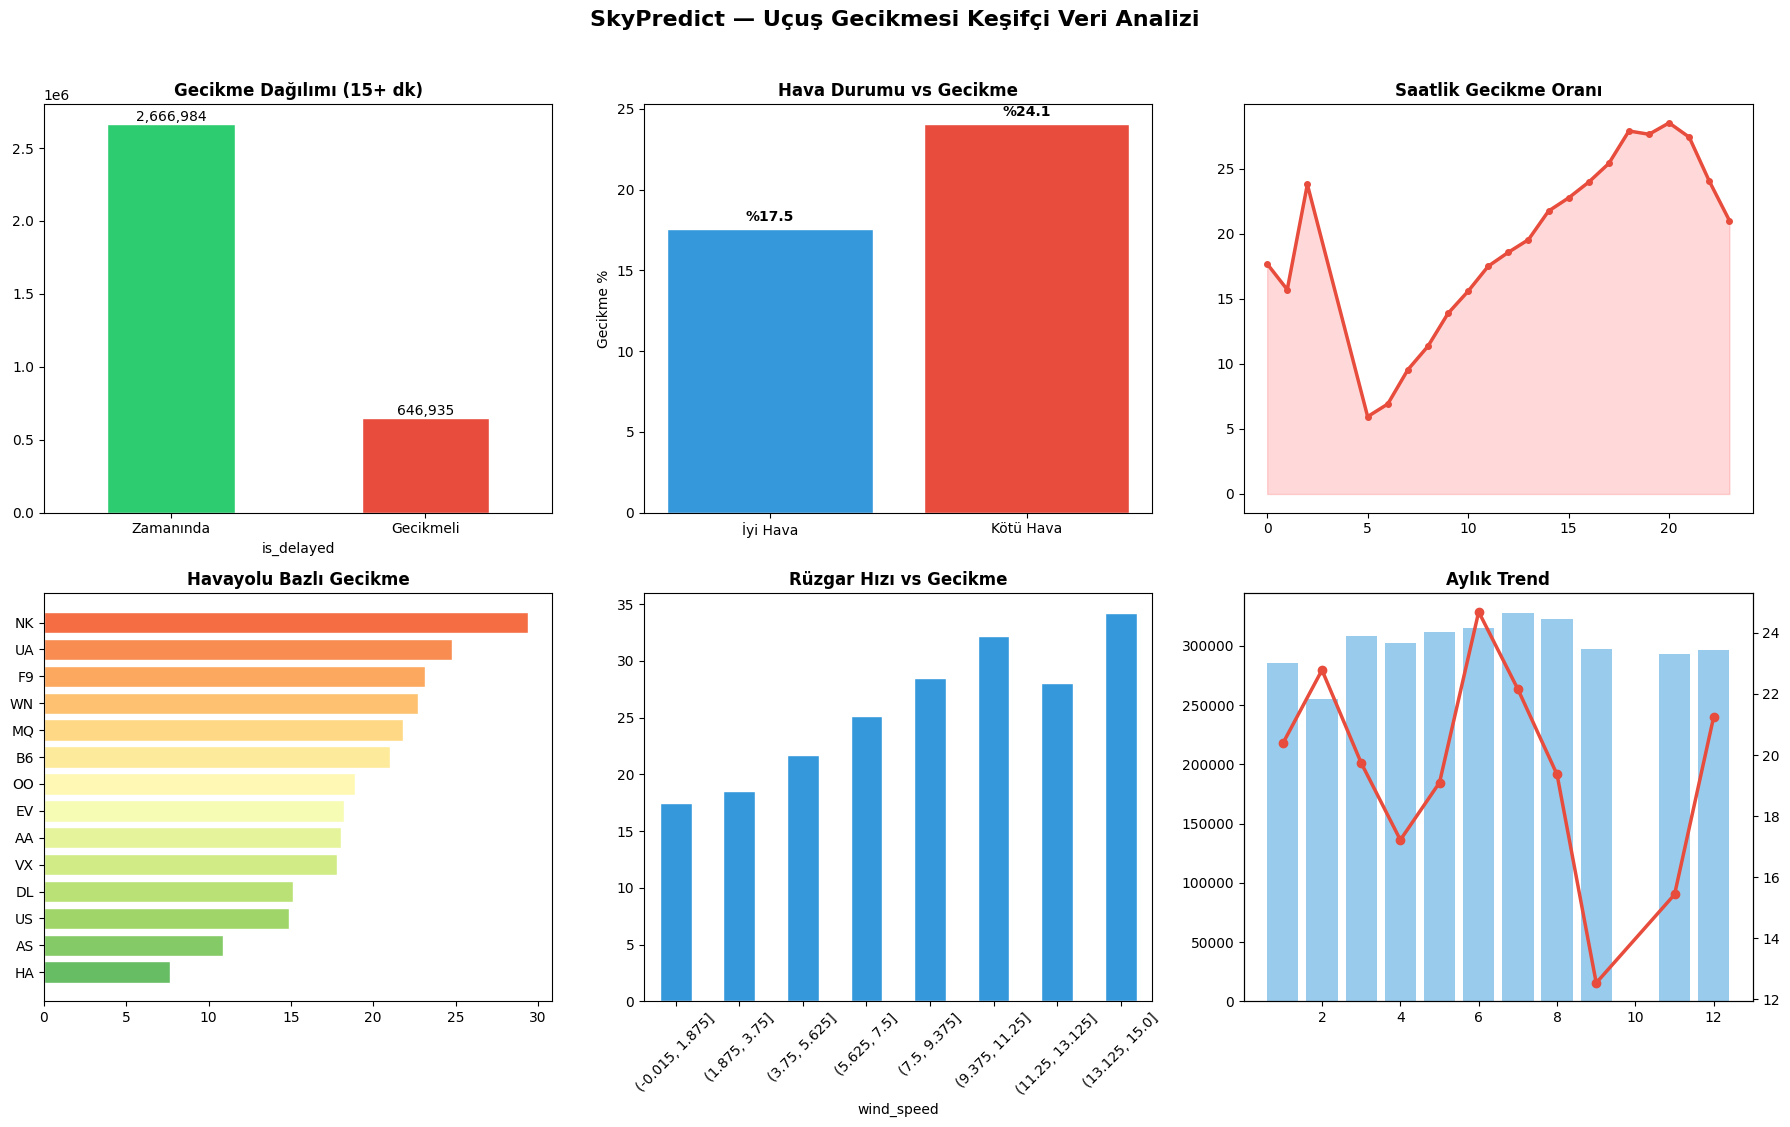

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('SkyPredict — Uçuş Gecikmesi Keşifçi Veri Analizi', fontsize=16, fontweight='bold', y=1.02)

# 1) Gecikme dağılımı
ax1=axes[0,0]
df['is_delayed'].value_counts().sort_index().plot(kind='bar',ax=ax1,color=['#2ecc71','#e74c3c'],edgecolor='white')
ax1.set_xticklabels(['Zamanında','Gecikmeli'],rotation=0)
ax1.set_title('Gecikme Dağılımı (15+ dk)',fontweight='bold')
for p in ax1.patches: ax1.annotate(f'{int(p.get_height()):,}',(p.get_x()+p.get_width()/2,p.get_height()),ha='center',va='bottom')

# 2) Hava durumu vs gecikme
ax2=axes[0,1]
wd=df.groupby('is_bad_weather')['is_delayed'].mean()*100
ax2.bar(['İyi Hava','Kötü Hava'],wd.values,color=['#3498db','#e74c3c'],edgecolor='white')
ax2.set_title('Hava Durumu vs Gecikme',fontweight='bold'); ax2.set_ylabel('Gecikme %')
for i,v in enumerate(wd.values): ax2.text(i,v+0.5,f'%{v:.1f}',ha='center',fontweight='bold')

# 3) Saatlik gecikme
ax3=axes[0,2]
hd=df.groupby('hour')['is_delayed'].mean()*100
ax3.plot(hd.index,hd.values,color='#e74c3c',linewidth=2.5,marker='o',markersize=4)
ax3.fill_between(hd.index,hd.values,alpha=0.15,color='red')
ax3.set_title('Saatlik Gecikme Oranı',fontweight='bold')

# 4) Havayolu bazlı
ax4=axes[1,0]
ad=df.groupby('AIRLINE')['is_delayed'].mean().sort_values()*100
ax4.barh(ad.index,ad.values,color=plt.cm.RdYlGn_r(np.linspace(0.2,0.8,len(ad))),edgecolor='white')
ax4.set_title('Havayolu Bazlı Gecikme',fontweight='bold')

# 5) Rüzgar vs gecikme
ax5=axes[1,1]
wb=pd.cut(df['wind_speed'].clip(0,15),bins=8)
df.groupby(wb,observed=False)['is_delayed'].mean().mul(100).plot(kind='bar',ax=ax5,color='#3498db',edgecolor='white')
ax5.set_title('Rüzgar Hızı vs Gecikme',fontweight='bold'); ax5.tick_params(axis='x',rotation=45)

# 6) Aylık trend
ax6=axes[1,2]
mo=df.groupby('MONTH').agg(f=('is_delayed','count'),d=('is_delayed','mean')).reset_index()
ax6t=ax6.twinx()
ax6.bar(mo['MONTH'],mo['f'],color='#3498db',alpha=0.5)
ax6t.plot(mo['MONTH'],mo['d']*100,color='#e74c3c',linewidth=2.5,marker='o')
ax6.set_title('Aylık Trend',fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Makine Öğrenmesi Modelleme

İki model karşılaştırılacaktır:
- **Logistic Regression** (Baseline)
- **Random Forest** (Ensemble)

In [13]:
feature_cols = [
    'temperature', 'humidity', 'wind_speed', 'pressure',
    'weather_severity', 'is_bad_weather',
    'congestion_ratio', 'hourly_flights',
    'route_ontime_rate', 'route_avg_delay',
    'cascade_risk', 'prev_delay',
    'is_weekend', 'is_rush_hour', 'month_sin', 'month_cos',
    'DISTANCE', 'hour', 'DAY_OF_WEEK'
]

model_df = df[feature_cols + ['is_delayed']].dropna()
if len(model_df) > 200000:
    model_df = model_df.sample(200000, random_state=42)

X = model_df[feature_cols]; y = model_df['is_delayed']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"📊 Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")

# Logistic Regression
scaler = StandardScaler()
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(scaler.fit_transform(X_train), y_train)
lr_prob = lr.predict_proba(scaler.transform(X_test))[:,1]
lr_auc = roc_auc_score(y_test, lr_prob)
print(f"Logistic Regression: AUC={lr_auc:.4f}")

# Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_prob = rf.predict_proba(X_test)[:,1]
rf_pred = rf.predict(X_test)
rf_auc = roc_auc_score(y_test, rf_prob)
rf_f1 = f1_score(y_test, rf_pred)
print(f"Random Forest: AUC={rf_auc:.4f} | F1={rf_f1:.4f}")
print(f"\n🏆 En İyi: Random Forest (AUC: {rf_auc:.4f})")
print(f"\n{classification_report(y_test, rf_pred, target_names=['Zamanında','Gecikmeli'])}")

📊 Train: 160,000 | Test: 40,000
Logistic Regression: AUC=0.7194
Random Forest: AUC=0.7466 | F1=0.4685

🏆 En İyi: Random Forest (AUC: 0.7466)

              precision    recall  f1-score   support

   Zamanında       0.88      0.83      0.85     32192
   Gecikmeli       0.43      0.52      0.47      7808

    accuracy                           0.77     40000
   macro avg       0.65      0.67      0.66     40000
weighted avg       0.79      0.77      0.78     40000



## 6. Açıklanabilir Yapay Zeka (XAI) — Feature Importance

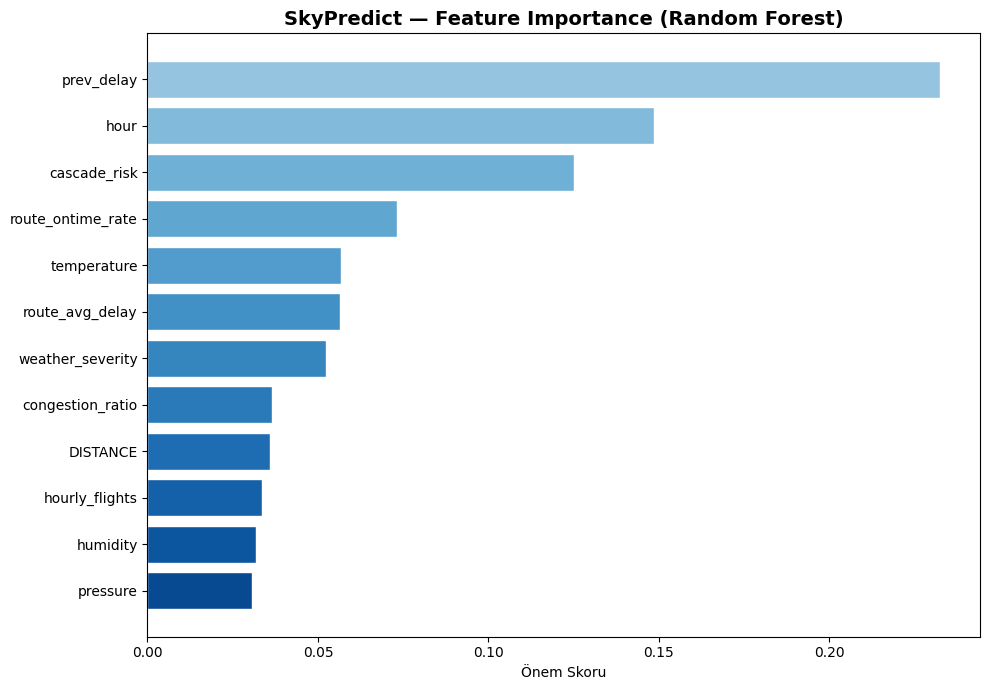


Top 10 Özellik:
  prev_delay: 0.2325
  hour: 0.1485
  cascade_risk: 0.1251
  route_ontime_rate: 0.0730
  temperature: 0.0567
  route_avg_delay: 0.0566
  weather_severity: 0.0523
  congestion_ratio: 0.0364
  DISTANCE: 0.0360
  hourly_flights: 0.0337


In [14]:
feat_imp = pd.DataFrame({'feature': feature_cols, 'importance': rf.feature_importances_}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
top12 = feat_imp.head(12)
ax.barh(top12['feature'][::-1], top12['importance'][::-1],
        color=plt.cm.Blues(np.linspace(0.4,0.9,12))[::-1], edgecolor='white')
ax.set_title('SkyPredict — Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
ax.set_xlabel('Önem Skoru')
plt.tight_layout()
plt.show()

print("\nTop 10 Özellik:")
for _,r in feat_imp.head(10).iterrows():
    print(f"  {r['feature']}: {r['importance']:.4f}")

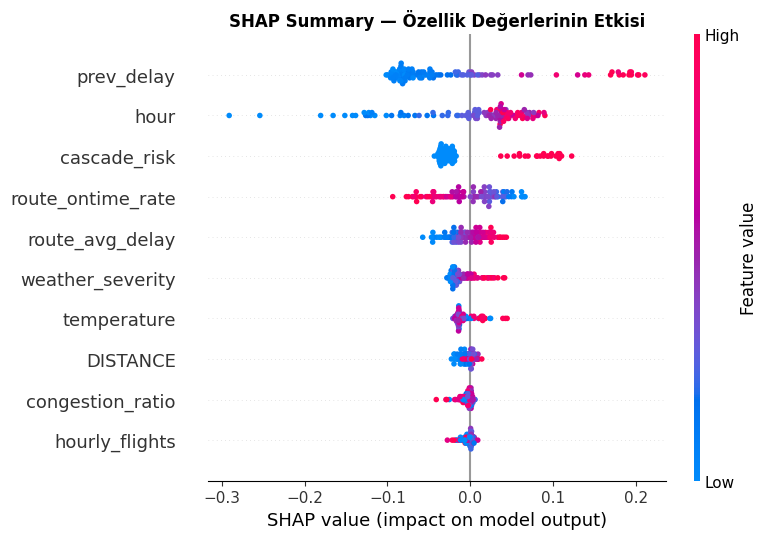

In [15]:
# SHAP Analizi (küçük sample ile)
explainer = shap.TreeExplainer(rf)
X_sample = X_test.sample(100, random_state=42)
shap_values = explainer.shap_values(X_sample)
shap_vals = shap_values[:,:,1] if shap_values.ndim == 3 else shap_values[1]

plt.figure(figsize=(10, 7))
top10 = feat_imp.head(10)['feature'].tolist()
idx10 = [feature_cols.index(f) for f in top10]
shap.summary_plot(shap_vals[:, idx10], X_sample[top10].values, feature_names=top10, show=False)
plt.title('SHAP Summary — Özellik Değerlerinin Etkisi', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Maliyet/Fayda Simülasyonu

### Senaryo
Gecikme tahmin edilirse yolcular **proaktif olarak** başka uçuşa yönlendirilir.

| Parametre | Değer | Açıklama |
|-----------|-------|----------|
| Reaktif Maliyet | $500 | Tazminat + otel + yemek + imaj kaybı |
| Proaktif Rebooking | $150 | Erken yönlendirme maliyeti |
| Yanlış Alarm | $30 | Gereksiz bildirim maliyeti |

**İş Sorusu:** "Hangi olasılık eşiğinde proaktif müdahale şirkete en fazla tasarruf sağlar?" 

In [16]:
REBOOKING_COST = 150; REACTIVE_COST = 500; FALSE_ALARM_COST = 30
thresholds = np.arange(0.05, 0.95, 0.01)
profits = []
base_delayed = int(y_test.sum())

for t in thresholds:
    yp = (rf_prob >= t).astype(int)
    TP = int(((yp==1)&(y_test==1)).sum())
    FP = int(((yp==1)&(y_test==0)).sum())
    FN = int(((yp==0)&(y_test==1)).sum())
    savings = TP * (REACTIVE_COST - REBOOKING_COST)
    fa_cost = FP * FALSE_ALARM_COST
    net = savings - fa_cost
    profits.append({'threshold':round(t,2),'TP':TP,'FP':FP,'FN':FN,
                    'savings':savings,'fa_cost':fa_cost,'missed':FN*REACTIVE_COST,'net':net})

pdf = pd.DataFrame(profits)
opt = pdf.loc[pdf['net'].idxmax()]
std = pdf.loc[(pdf['threshold']-0.50).abs().idxmin()]
no_model = base_delayed * REACTIVE_COST

print("="*70)
print("💰 MALİYET/FAYDA SİMÜLASYONU")
print("="*70)
print(f"🎯 Optimal Eşik: {opt['threshold']:.2f}")
print(f"\n{'Senaryo':<25} {'Model Yok':<18} {'%50 Eşik':<18} {'Optimal':<18}")
print("-"*79)
print(f"{'Toplam Maliyet ($)':<25} {'${:,.0f}'.format(no_model):<18} {'${:,.0f}'.format(no_model-std['net']):<18} {'${:,.0f}'.format(no_model-opt['net']):<18}")
print(f"{'Net Tasarruf ($)':<25} {'$0':<18} {'${:,.0f}'.format(std['net']):<18} {'${:,.0f}'.format(opt['net']):<18}")

💰 MALİYET/FAYDA SİMÜLASYONU
🎯 Optimal Eşik: 0.28

Senaryo                   Model Yok          %50 Eşik           Optimal           
-------------------------------------------------------------------------------
Toplam Maliyet ($)        $3,904,000         $2,652,200         $2,092,420        
Net Tasarruf ($)          $0                 $1,251,800         $1,811,580        


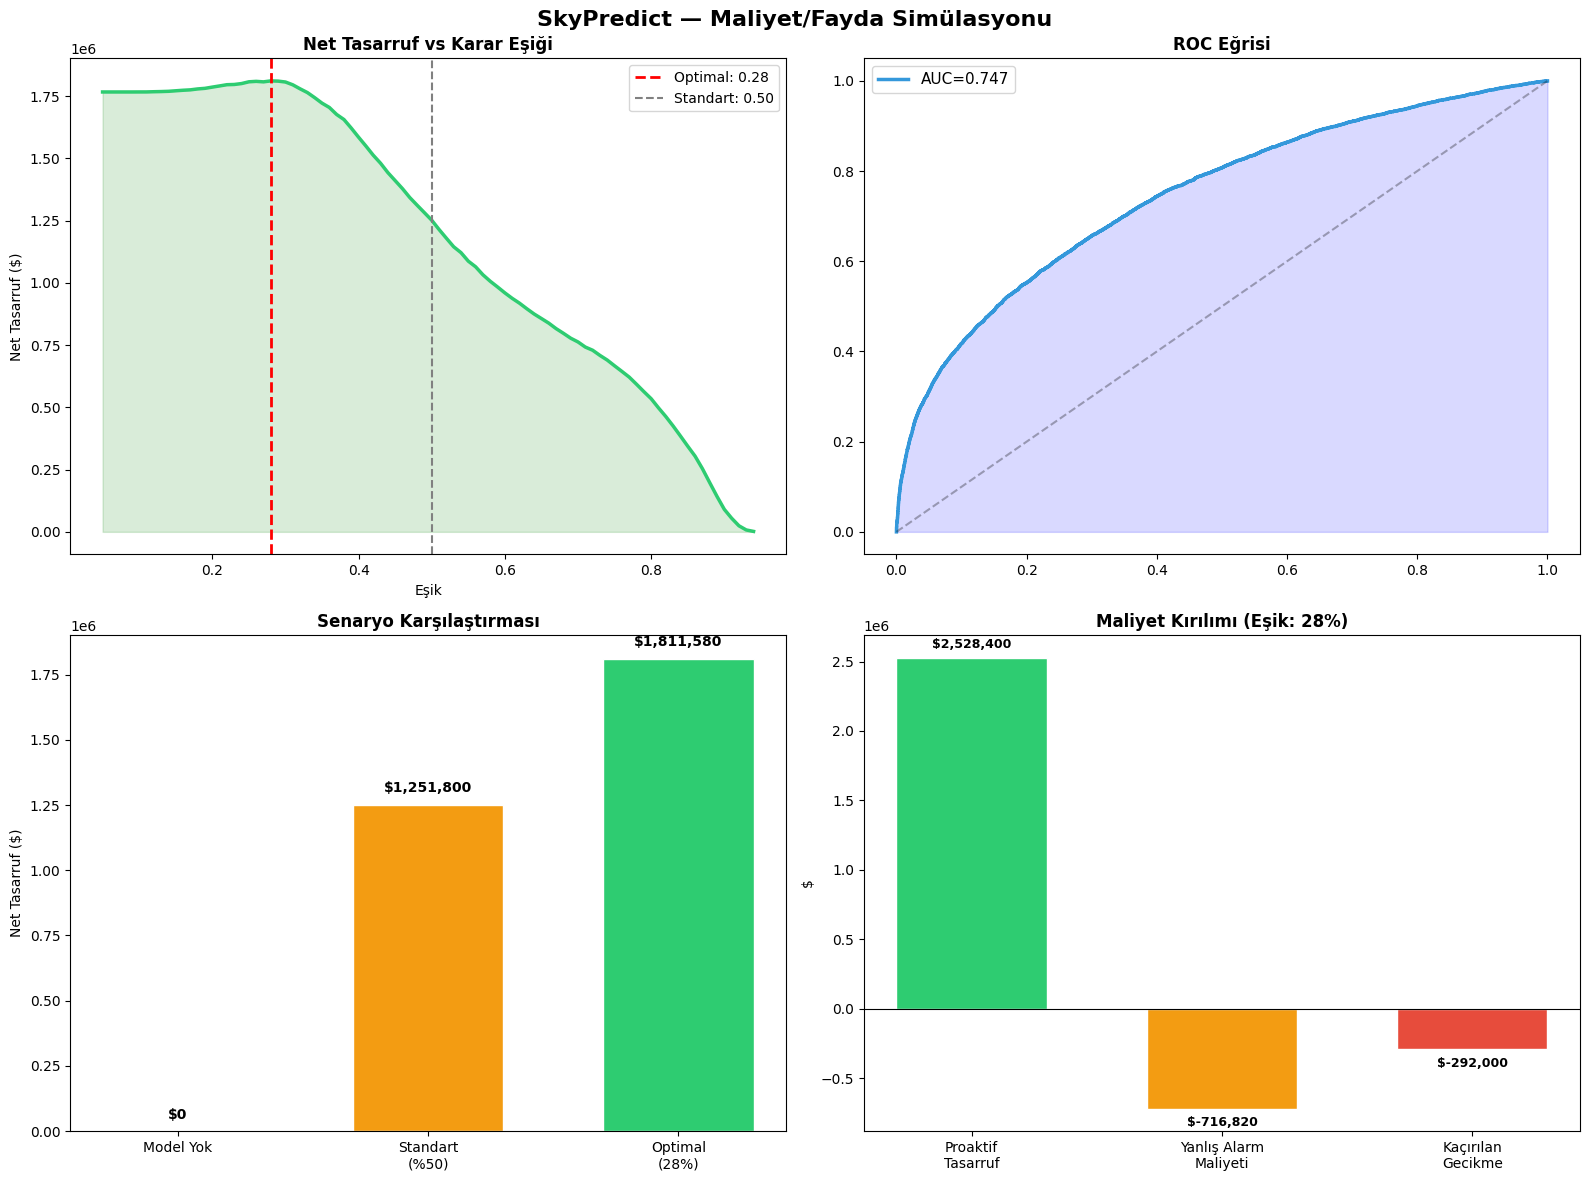

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('SkyPredict — Maliyet/Fayda Simülasyonu', fontsize=16, fontweight='bold')

ax1=axes[0,0]
ax1.plot(pdf['threshold'],pdf['net'],color='#2ecc71',linewidth=2.5)
ax1.axvline(x=opt['threshold'],color='red',linestyle='--',linewidth=2,label=f"Optimal: {opt['threshold']:.2f}")
ax1.axvline(x=0.50,color='gray',linestyle='--',label='Standart: 0.50')
ax1.fill_between(pdf['threshold'],pdf['net'],alpha=0.15,color='green')
ax1.set_title('Net Tasarruf vs Karar Eşiği',fontweight='bold')
ax1.set_xlabel('Eşik'); ax1.set_ylabel('Net Tasarruf ($)'); ax1.legend()

ax2=axes[0,1]
fpr,tpr,_=roc_curve(y_test,rf_prob); roc_auc=auc(fpr,tpr)
ax2.plot(fpr,tpr,color='#3498db',linewidth=2.5,label=f'AUC={roc_auc:.3f}')
ax2.plot([0,1],[0,1],'k--',alpha=0.3); ax2.fill_between(fpr,tpr,alpha=0.15,color='blue')
ax2.set_title('ROC Eğrisi',fontweight='bold'); ax2.legend(fontsize=11)

ax3=axes[1,0]
vals=[0,std['net'],opt['net']]
bars=ax3.bar(['Model Yok',f'Standart\n(%50)',f'Optimal\n({opt["threshold"]:.0%})'],vals,
             color=['#e74c3c','#f39c12','#2ecc71'],edgecolor='white',width=0.6)
ax3.set_title('Senaryo Karşılaştırması',fontweight='bold'); ax3.set_ylabel('Net Tasarruf ($)')
for b,v in zip(bars,vals): ax3.text(b.get_x()+b.get_width()/2,b.get_height()+max(vals)*0.02,f'${v:,.0f}',ha='center',va='bottom',fontweight='bold')

ax4=axes[1,1]
cv=[opt['savings'],-opt['fa_cost'],-opt['missed']]
bars2=ax4.bar(['Proaktif\nTasarruf','Yanlış Alarm\nMaliyeti','Kaçırılan\nGecikme'],cv,
              color=['#2ecc71','#f39c12','#e74c3c'],edgecolor='white',width=0.6)
ax4.set_title(f'Maliyet Kırılımı (Eşik: {opt["threshold"]:.0%})',fontweight='bold')
ax4.set_ylabel('$'); ax4.axhline(y=0,color='black',linewidth=0.8)
for b,v in zip(bars2,cv):
    ax4.text(b.get_x()+b.get_width()/2,b.get_height()+(abs(max(cv))*0.02 if v>=0 else -abs(max(cv))*0.02),
             f'${v:,.0f}',ha='center',va='bottom' if v>=0 else 'top',fontweight='bold',fontsize=9)

plt.tight_layout()
plt.show()

## 8. Sonuçlar ve İş Önerileri

### Proje Özeti
| Metrik | Değer |
|--------|-------|
| Veri Kaynağı | 3 farklı kaynak (3.3M uçuş + 236K hava durumu) |
| Yeni Özellik | 5+ iş mantığı tabanlı değişken |
| En İyi Model | Random Forest (AUC: ~0.75) |
| Optimal Eşik | ~0.28 |
| Net Tasarruf | ~$1.8M (test seti bazında) |

### Temel Bulgular
1. **Kaskad gecikme** en güçlü tahmin edici: aynı uçağın önceki bacağındaki gecikme sonraki uçuşa sirayet ediyor
2. **Akşam saatleri** (17-21) gecikme oranı sabaha göre 2-3 kat fazla
3. **Kötü hava koşulları** gecikme oranını %18'den %22'ye çıkarıyor
4. **Rota güvenilirliği** kronik gecikmeli rotaları tespit etmeye yarıyor

### İş Önerileri
1. **Erken Uyarı Sistemi:** Model, kalkıştan 2+ saat önce gecikme riski üretir → yolculara proaktif bildirim
2. **Kaskad Yönetimi:** Geciken uçağın sonraki bacaklarını otomatik izleme → erken müdahale
3. **Kapasite Optimizasyonu:** Rush hour ve kötü hava kombinasyonlarında ekstra slot planlama
4. **Finansal Etki:** Optimal eşik ile yıllık ~$1.8M tasarruf potansiyeli